In [3]:
from datasets import load_dataset

raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

def dataset_split_to_text(split):
    return "\n".join(raw[split]["text"])

train_text = dataset_split_to_text("train")
val_text = dataset_split_to_text("validation") 
test_text = dataset_split_to_text("test")

## Configuration & reproducibility

**What changed and why**: the original notebook scattered hyperparameters as literals across each `train_*` call, used no random seed, and shared a single learning rate across all three architectures. That makes it impossible to know whether a difference between models reflects architecture, an unlucky init, or an LR that happened to suit one architecture better. The updated code is now declared once, explicitly, so every run states exactly what it controlled for.

In [1]:
import random
import numpy as np
import torch
import nltk

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

nltk.download('punkt_tab')  

# --- reproducibility & config -------------------------------
SEED = 1337                              # default / quick-run seed
SEEDS_FOR_FINAL_RUN = [1337, 2024, 7]    # seeds averaged over for reported numbers

def set_seed(seed):
    """Reset randomness before each model run for fair comparisons."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed) # PyTorch CPU randomness
    torch.cuda.manual_seed_all(seed) # PyTorch GPU randomness

set_seed(SEED)

# Test whether the architecture gap widens with context length. 
# At seq_len=6 an LSTM's persistent state and a transformer's global attention have almost no room to show a difference over a plain GRU gate, so a 
# single short seq_len can't really answer an "inductive bias" question.
SEQ_LEN = 6
SEQ_LEN_LONG = 30

NUM_SENTENCES_TRAIN = 25000
NUM_SENTENCES_VAL = 5000
NUM_SENTENCES_TEST = 5000

BATCH_SIZE = 200
NUM_EPOCHS = 10
GRAD_CLIP_NORM = 0.5
EMBEDDING_DIM = 100
HIDDEN_SIZE = 128       # LSTM/GRU hidden size; transformer's dim_feedforward is
                         # searched separately below to param-match the LSTM.
DROPOUT_P = 0.1

# Use architecture-specific learning rates for fairer optimization.
# Previously lr=1e-3 was shared across all three architectures. That confounds
# "architecture" with "optimization mismatch": transformers are well known to be
# more sensitive to learning rate (and to the absence of a warmup schedule) than
# RNNs. LR_BY_ARCH lets each architecture use its own rate.
LR_BY_ARCH = {
    "lstm": 1e-3,
    "gru": 1e-3,
    "transformer": 5e-4,
}

# Quick mode uses one seed and one sequence length.
# Full mode runs all seeds and both sequence lengths.

QUICK_MODE = True  
SEEDS_TO_RUN = SEEDS_FOR_FINAL_RUN[:1] if QUICK_MODE else SEEDS_FOR_FINAL_RUN  # One seed or all seeds
SEQ_LENS_TO_RUN = [SEQ_LEN] if QUICK_MODE else [SEQ_LEN, SEQ_LEN_LONG] # One or both context lengths


Using device: cpu


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shannonchiang/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from nltk import word_tokenize, sent_tokenize
import gc
import torch
from torch import tensor
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from datasets import load_dataset

def load_data(split_name):
    """Return the full text of a WikiText-2 split as one string."""
    return "\n".join(raw_dataset[split_name]["text"])

def clean_data(data):
    data = re.sub(r'@-@', '-', data)
    data = re.sub(r'@\.@', '.', data)
    data = re.sub(r'@,@', ',', data)
    repl = ''
    data = re.sub('\(', repl, data)
    data = re.sub('\)', repl, data)
    for pattern in set(re.findall("=.*=", data)):
        data = re.sub(pattern, repl, data)
    for pattern in set(re.findall("<unk>", data)):
        data = re.sub(pattern, repl, data)
    for pattern in set(re.findall(r"[^\w ]", data)):
        repl = ''
        if pattern == '-':
            repl = ''
        if pattern != '.' and pattern != "\'":
            data = re.sub("\\" + pattern, repl, data)
    return data

def corpus_stats(splits, top_n=10):
    stats = {}
    all_words = set()
    top_words = {}
    for split_name in splits:
        raw = load_data(split_name)
        cleaned = clean_data(raw)
        tokens = cleaned.split()
        split_vocab = set(tokens)
        all_words.update(split_vocab)
        counts = Counter(tokens)
        top_words[split_name] = counts.most_common(top_n)

        stats[split_name] = {
            'num_tokens': len(tokens),
            'vocab_size': len(split_vocab)
        }

    stats_df = pd.DataFrame(stats).T[['num_tokens', 'vocab_size']]

    print("Corpus statistics: ")
    print(stats_df)
    print(f"\nCombined vocabulary size across all splits: {len(all_words)}")
    for split_name in splits:
        print(f"\nTop {top_n} most frequent words in {split_name}: ")
        for word, count in top_words[split_name]:
            print(f" {word}: {count}")

    return stats_df, len(all_words), top_words

raw_dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

splits = ["train", "validation", "test"]
stats_df, combined_vocab, top_words = corpus_stats(splits, top_n=10)

Corpus statistics: 
            num_tokens  vocab_size
train          1815485       75936
validation      190396       19681
test            214534       20866

Combined vocabulary size across all splits: 83855

Top 10 most frequent words in train: 
 the: 113006
 .: 76577
 of: 56603
 and: 49807
 in: 39384
 to: 39132
 a: 34225
 was: 20985
 The: 17509
 that: 14134

Top 10 most frequent words in validation: 
 the: 12611
 .: 8033
 of: 5880
 and: 5254
 in: 4254
 to: 4123
 a: 3439
 was: 2324
 The: 2074
 on: 1511

Top 10 most frequent words in test: 
 the: 13989
 .: 9440
 of: 6731
 and: 5780
 to: 4725
 in: 4495
 a: 3786
 was: 2575
 The: 2066
 on: 1610


In [3]:
def split_data(data, num_sentences = -1):

    #sentence tokenization
    if num_sentences == -1:
        sentences = sent_tokenize(data)
    else:
        sentences = sent_tokenize(data)[:num_sentences]

    #word tokenization
    words = set()
    for sent in sentences:
        for word in str.split(sent, ' '):
            words.add(word)
    words = list(words)

    #add empty string (padding zeros) in list of words to avoid confusion while padding
    words.insert(0, "")

    return sentences, words

In [4]:
def convert_data(sentences, words, seq_len, word_ind=None, ind_word=None,
                  pad_token='<pad>', unk_token='<unk>'):
    # ensure special tokens exist in the vocabulary
    words = list(dict.fromkeys(words))   # de-duplicates while preserving order
    if pad_token not in words:
        words.append(pad_token)
    if unk_token not in words:
        words.append(unk_token)

    # build lookup dicts once, or reuse ones passed in (e.g. from train)
    if word_ind is None or ind_word is None:
        word_ind = {w: i for i, w in enumerate(words)}
        ind_word = {i: w for i, w in enumerate(words)}

    pad_idx = word_ind[pad_token]
    unk_idx = word_ind[unk_token]

    # build (predictor window, next word) pairs via a sliding window
    predictors, class_labels = [], []
    for sentence in sentences:
        tokens = [t for t in sentence.split(' ') if t != '']
        for j in range(1, len(tokens)):
            start = max(0, j - seq_len)
            predictors.append(tokens[start:j])
            class_labels.append(tokens[j])

    # left-pad each window with pad_token up to seq_len
    pad_predictors = []
    for seq in predictors:
        pad_len = seq_len - len(seq)
        pad_predictors.append([pad_token] * pad_len + seq)

    # encode to indices, falling back to <unk> for unseen words
    encoded_predictors = [
        [word_ind.get(w, unk_idx) for w in seq] for seq in pad_predictors
    ]
    encoded_labels = [word_ind.get(w, unk_idx) for w in class_labels]

    pad_predictors_tensor = torch.stack(
        [torch.tensor(seq, dtype=torch.long) for seq in encoded_predictors]
    )
    class_labels_tensor = torch.tensor(encoded_labels, dtype=torch.long)

    return pad_predictors_tensor, class_labels_tensor, word_ind, ind_word

In [5]:
class LSTM(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size):
        super(LSTM, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.padding_idx = padding_idx
        self.hidden_size = hidden_size
        self.dropout = Dropout_p
        self.batch_size = batch_size
        # add Embedding Layer
        self.Embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=padding_idx)  
        # add LSTM Layer
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=1, batch_first=True)
        # add Dropout Layer
        self.dropout = nn.Dropout(Dropout_p)
        # add fully connected dense Layer
        self.FC = nn.Linear(hidden_size, num_embeddings)
        
    def init_hidden(self, batch_size):
        device = next(self.parameters()).device
        state_h = torch.zeros(1, batch_size, self.hidden_size, device=device)
        state_c = torch.zeros(1, batch_size, self.hidden_size, device=device)
        return (state_h, state_c)
        
    def forward(self, input_sequence, state_h, state_c):
        Embed_input = self.Embedding(input_sequence)
        output, (state_h, state_c) = self.lstm(Embed_input, (state_h, state_c))
        logits = self.FC(output[:, -1, :])
        return logits, (state_h, state_c)
        
    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices = torch.topk(logits_softmax[0], k=topk)
        choices = indices.tolist()
        sampling = random.sample(choices, 1)
        return ind_word[sampling[0]]


In [6]:
def get_batch(pad_predictors, class_labels, batch_size, device=None):
    for i in range(0, len(pad_predictors), batch_size):
        if i + batch_size < len(pad_predictors):
            x, y = pad_predictors[i:i+batch_size], class_labels[i:i+batch_size]
            if device is not None:
                x, y = x.to(device), y.to(device)
            yield x, y


In [7]:
import time

# Uses shared experiment settings: learning rate, hidden size, gradient clipping

def train_lstm(pad_predictors, class_labels, n_vocab, embedding_dim, padding_idx,
                hidden_size, Dropout_p, batch_size, lr, num_epochs=10, seed=None,
                val_pad_predictors=None, val_class_labels=None, grad_clip_norm=GRAD_CLIP_NORM,
                word_ind=None, seq_len=None):
    if seed is not None:
        set_seed(seed) # resets the random seed before training for reproducibility
    model = LSTM(n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=padding_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_times = []          # wall time (kept for reference / comparability with the old plots)
    epoch_cpu_times = []      # time.process_time(): the fair, load-independent timing metric
    epoch_losses = []
    epoch_val_ppls = []       # validation perplexity checkpointed every epoch
    cumulative_cpu_time = []
    total_start = time.time()
    total_cpu_start = time.process_time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        epoch_cpu_start = time.process_time()
        state_h, state_c = model.init_hidden(batch_size)

        total_loss = 0
        for x, y in get_batch(pad_predictors, class_labels, batch_size, device=DEVICE):
            model.train()
            state_h = state_h.detach()
            state_c = state_c.detach()

            logits, (state_h, state_c) = model(x, state_h, state_c)
            loss = criterion(logits, y)
            loss_value = loss.item()
            total_loss += len(x) * loss_value

            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            optimizer.step()

        total_loss /= len(pad_predictors)
        epoch_elapsed = time.time() - epoch_start
        epoch_cpu_elapsed = time.process_time() - epoch_cpu_start
        epoch_times.append(epoch_elapsed)
        epoch_cpu_times.append(epoch_cpu_elapsed)
        epoch_losses.append(total_loss)
        cumulative_cpu_time.append(time.process_time() - total_cpu_start)

        print(f"Epoch[{epoch+1} / {num_epochs}] Loss: {total_loss}, perplexity: {np.exp(total_loss)}, "
              f"wall_time: {epoch_elapsed:.2f}s, cpu_time: {epoch_cpu_elapsed:.2f}s")

        if val_pad_predictors is not None:
            val_loss, val_ppl = evaluate(model, val_pad_predictors, val_class_labels, batch_size=batch_size)
            epoch_val_ppls.append(val_ppl)
            print(f"  val_loss: {val_loss:.4f}, val_ppl: {val_ppl:.2f}")

        gen_text = generate(model, init='The', sent_len=100, topk=5, word_ind=word_ind, seq_len=seq_len)
        print(f"Text generated after epoch {epoch}:\n{gen_text}\n")

    total_elapsed = time.time() - total_start
    total_cpu_elapsed = time.process_time() - total_cpu_start
    print(f"\nTotal training time: {total_elapsed:.2f}s wall / {total_cpu_elapsed:.2f}s cpu")
    print(f"Median cpu time per epoch: {np.median(epoch_cpu_times):.2f}s")

    return model, total_loss, epoch_times, epoch_losses, total_elapsed, {
        "epoch_cpu_times": epoch_cpu_times,
        "cumulative_cpu_time": cumulative_cpu_time,
        "epoch_val_ppls": epoch_val_ppls,
        "total_cpu_time": total_cpu_elapsed,
    }


In [8]:
import inspect
print(inspect.getsource(LSTM.topk_sampling))


    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices = torch.topk(logits_softmax[0], k=topk)
        choices = indices.tolist()
        sampling = random.sample(choices, 1)
        return ind_word[sampling[0]]



GRU: 2 gates, no cell state, trains faster
LSTM: 3 gates, one cell state

In [9]:

class GRU(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size):
        super(GRU, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.padding_idx = padding_idx
        self.hidden_size = hidden_size
        self.dropout = Dropout_p
        self.batch_size = batch_size
        self.Embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(Dropout_p)
        self.FC = nn.Linear(hidden_size, num_embeddings)
    def init_hidden(self, batch_size):
        device = next(self.parameters()).device
        state_h = torch.zeros(1, batch_size, self.hidden_size, device=device)
        return state_h  # one state, no cell state
    def forward(self, input_sequence, state_h):
        Embed_input = self.Embedding(input_sequence)
        output, state_h = self.gru(Embed_input, state_h)
        logits = self.FC(output[:, -1, :])
        return logits, state_h
    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices, = torch.topk(logits_softmax[0], k=topk)
        choices = indices.tolist()
        sampling = random.sample(choices, 1)
        return ind_word[sampling[0]]

In [10]:
def train_gru(pad_predictors, class_labels, n_vocab, embedding_dim, padding_idx,
              hidden_size, Dropout_p, batch_size, lr, num_epochs=10, seed=None,
              val_pad_predictors=None, val_class_labels=None, grad_clip_norm=GRAD_CLIP_NORM,
              word_ind=None, seq_len=None):
    if seed is not None:
        set_seed(seed)
    model = GRU(n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=padding_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_times = []
    epoch_cpu_times = []
    epoch_losses = []
    epoch_val_ppls = []
    cumulative_cpu_time = []
    total_start = time.time()
    total_cpu_start = time.process_time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        epoch_cpu_start = time.process_time()
        state_h = model.init_hidden(batch_size)  

        total_loss = 0
        for x, y in get_batch(pad_predictors, class_labels, batch_size, device=DEVICE):
            model.train()
            state_h = state_h.detach()

            logits, state_h = model(x, state_h)
            loss = criterion(logits, y)
            loss_value = loss.item()
            total_loss += len(x) * loss_value

            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            optimizer.step()

        total_loss /= len(pad_predictors)
        epoch_elapsed = time.time() - epoch_start
        epoch_cpu_elapsed = time.process_time() - epoch_cpu_start
        epoch_times.append(epoch_elapsed)
        epoch_cpu_times.append(epoch_cpu_elapsed)
        epoch_losses.append(total_loss)
        cumulative_cpu_time.append(time.process_time() - total_cpu_start)

        print(f"Epoch[{epoch+1} / {num_epochs}] Loss: {total_loss}, perplexity: {np.exp(total_loss)}, "
              f"wall_time: {epoch_elapsed:.2f}s, cpu_time: {epoch_cpu_elapsed:.2f}s")

        if val_pad_predictors is not None:
            val_loss, val_ppl = evaluate(model, val_pad_predictors, val_class_labels, batch_size=batch_size)
            epoch_val_ppls.append(val_ppl)
            print(f"  val_loss: {val_loss:.4f}, val_ppl: {val_ppl:.2f}")

        gen_text = generate(model, init='The', sent_len=100, topk=5, word_ind=word_ind, seq_len=seq_len)
        print(f"Text generated after epoch {epoch}:\n{gen_text}\n")

    total_elapsed = time.time() - total_start
    total_cpu_elapsed = time.process_time() - total_cpu_start
    print(f"\nTotal training time: {total_elapsed:.2f}s wall / {total_cpu_elapsed:.2f}s cpu")
    print(f"Median cpu time per epoch: {np.median(epoch_cpu_times):.2f}s")

    return model, total_loss, epoch_times, epoch_losses, total_elapsed, {
        "epoch_cpu_times": epoch_cpu_times,
        "cumulative_cpu_time": cumulative_cpu_time,
        "epoch_val_ppls": epoch_val_ppls,
        "total_cpu_time": total_cpu_elapsed,
    }


In [11]:
class TransformerModel(nn.Module):
    def __init__(self, n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size,
                 nhead=4, nlayers=2, max_len=512):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Embedding(n_vocab, embedding_dim, padding_idx=padding_idx)
        self.pos_embedding = nn.Embedding(max_len, embedding_dim)
        self.drop = nn.Dropout(Dropout_p)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=hidden_size,
            dropout=Dropout_p,
            batch_first=True,   
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.fc = nn.Linear(embedding_dim, n_vocab)

        self.padding_idx = padding_idx

    def forward(self, x):
        # x: (batch, seq_len)
        bsz, seq_len = x.shape
        device = x.device

        pos_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(bsz, seq_len)
        e = self.drop(self.embedding(x) + self.pos_embedding(pos_ids))

        # causal mask: position i can't attend to positions > i
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)

        # padding mask: True where x is padding, so attention ignores those positions
        padding_mask = (x == self.padding_idx)

        out = self.encoder(e, mask=causal_mask, src_key_padding_mask=padding_mask, is_causal=True)
        out = torch.nan_to_num(out, nan=0.0)  # zero out NaNs from fully-masked rows
    
        logits = self.fc(out[:, -1, :])  # predict next word from the last position
        return logits, None
 
    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices=torch.topk(logits_softmax[0], k=topk)
        choices=indices.tolist()
        sampling=random.sample(choices, 1)

        return ind_word[sampling[0]]


In [12]:
def train_transformer(pad_predictors, class_labels, n_vocab, embedding_dim, padding_idx, hidden_size,
                       Dropout_p, batch_size, lr, num_epochs=10, seed=None,
                       val_pad_predictors=None, val_class_labels=None, grad_clip_norm=GRAD_CLIP_NORM,
                       word_ind=None, seq_len=None):
    if seed is not None:
        set_seed(seed)
    model = TransformerModel(n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=padding_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_times = []
    epoch_cpu_times = []
    epoch_losses = []
    epoch_val_ppls = []
    cumulative_cpu_time = []
    total_start = time.time()
    total_cpu_start = time.process_time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        epoch_cpu_start = time.process_time()
        total_loss = 0

        for x, y in get_batch(pad_predictors, class_labels, batch_size, device=DEVICE):
            model.train()
            logits, _ = model(x)  # no state passed in

            loss = criterion(logits, y)
            loss_value = loss.item()
            total_loss += len(x) * loss_value

            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            optimizer.step()

        total_loss /= len(pad_predictors)
        epoch_elapsed = time.time() - epoch_start
        epoch_cpu_elapsed = time.process_time() - epoch_cpu_start
        epoch_times.append(epoch_elapsed)
        epoch_cpu_times.append(epoch_cpu_elapsed)
        epoch_losses.append(total_loss)
        cumulative_cpu_time.append(time.process_time() - total_cpu_start)

        print(f"Epoch[{epoch+1} / {num_epochs}] Loss: {total_loss}, perplexity: {np.exp(total_loss)}, "
              f"wall_time: {epoch_elapsed:.2f}s, cpu_time: {epoch_cpu_elapsed:.2f}s")

        if val_pad_predictors is not None:
            val_loss, val_ppl = evaluate(model, val_pad_predictors, val_class_labels, batch_size=batch_size)
            epoch_val_ppls.append(val_ppl)
            print(f"  val_loss: {val_loss:.4f}, val_ppl: {val_ppl:.2f}")

        gen_text = generate_transformer(model, init='The', sent_len=100, topk=5, word_ind=word_ind, seq_len=seq_len)
        print(f"Text generated after epoch {epoch}:\n{gen_text}\n")

    total_elapsed = time.time() - total_start
    total_cpu_elapsed = time.process_time() - total_cpu_start
    print(f"\nTotal training time: {total_elapsed:.2f}s wall / {total_cpu_elapsed:.2f}s cpu")
    print(f"Median cpu time per epoch: {np.median(epoch_cpu_times):.2f}s")

    return model, total_loss, epoch_times, epoch_losses, total_elapsed, {
        "epoch_cpu_times": epoch_cpu_times,
        "cumulative_cpu_time": cumulative_cpu_time,
        "epoch_val_ppls": epoch_val_ppls,
        "total_cpu_time": total_cpu_elapsed,
    }


In [13]:
@torch.no_grad()
def evaluate(model, pad_predictors, class_labels, batch_size=200):
    model.eval()
    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss(reduction='none') # per-example loss, not averaged

    total_loss = 0
    total_count = 0

    state = model.init_hidden(batch_size) if hasattr(model, "init_hidden") else None
    if isinstance(state, tuple):
        state = tuple(s.detach() for s in state)
    elif state is not None:
        state = state.detach()

    for x, y in get_batch(pad_predictors, class_labels, batch_size, device=device):
        if state is None:
            logits = model(x)            # transformer: no recurrent state
            if isinstance(logits, tuple):
                logits = logits[0]
        elif isinstance(state, tuple):
            logits, state = model(x, *state)       # lstm: (state_h, state_c)
            state = tuple(s.detach() for s in state)
        else:
            logits, state = model(x, state)     # gru: single state
            state = state.detach()

        losses = criterion(logits, y)  # shape (batch,)
        valid_mask = (x[:, 0] != model.padding_idx) if hasattr(model, 'padding_idx') else torch.ones_like(losses, dtype=torch.bool)
        losses = losses[valid_mask]

        total_loss += losses.sum().item()
        total_count += len(losses)
    

    total_loss /= total_count
    return total_loss, float(np.exp(total_loss))

In [14]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def match_transformer_hidden_size(target_params, n_vocab, embedding_dim, padding_idx,
                                    dropout_p, batch_size, nhead=4, nlayers=2,
                                    search_range=range(64, 512, 4), tolerance=0.01):
    """Search dim_feedforward values for the transformer so its total parameter
    count lands within `tolerance` (fraction) of target_params (the LSTM's count),
    instead of accepting whatever count falls out of a hidden_size chosen for the RNNs."""
    best_hidden, best_diff, best_params = None, float("inf"), None
    for h in search_range:
        m = TransformerModel(n_vocab, embedding_dim, padding_idx, h, dropout_p, batch_size,
                              nhead=nhead, nlayers=nlayers)
        p = count_params(m)
        diff = abs(p - target_params) / target_params
        if diff < best_diff:
            best_diff, best_hidden, best_params = diff, h, p
        if diff <= tolerance:
            return h, p, diff
    print(f"Warning: no dim_feedforward in search_range matched within {tolerance:.1%}; "
          f"using closest found (diff={best_diff:.1%})")
    return best_hidden, best_params, best_diff


In [15]:
# per-architecture learning-rate sweep
def lr_sweep(train_fn, lr_grid, sweep_epochs, pad_predictors, class_labels,
             val_pad_predictors, val_class_labels, seed=SEED, **train_kwargs):
    """Short training run at each candidate LR for one architecture's train_fn;
    reports validation loss/perplexity at each so you can pick a fair per-architecture rate."""
    scores = {}
    for lr in lr_grid:
        set_seed(seed)
        model, *_ = train_fn(
            pad_predictors, class_labels, lr=lr, num_epochs=sweep_epochs,
            val_pad_predictors=val_pad_predictors, val_class_labels=val_class_labels,
            **train_kwargs,
        )
        val_loss, val_ppl = evaluate(model, val_pad_predictors, val_class_labels, batch_size=BATCH_SIZE)
        scores[lr] = (val_loss, val_ppl)
        print(f"  lr={lr:>8}: val_loss={val_loss:.4f}  val_ppl={val_ppl:.1f}")
    best_lr = min(scores, key=lambda lr: scores[lr][0])
    print(f"Best lr: {best_lr}")
    return best_lr, scores

In [16]:
def prepare_test_data(words, seq_len, num_sentences=6000):
    test_raw = load_data("test")
    data = clean_data(test_raw[:])
    sentences, _ = split_data(data, num_sentences=num_sentences)
    pad_predictors, class_labels, _, _ = convert_data(
        sentences, words, seq_len, word_ind=word_ind, ind_word=ind_word
    )

    words = list(word_ind.keys())
    
    return convert_data(sentences, words, seq_len)


In [17]:
def generate(model, init, sent_len, topk, word_ind=None, seq_len=None):
    # fall back to global vocabulary/settings for manual calls
    if word_ind is None:
        word_ind = globals()['word_ind']
    if seq_len is None:
        seq_len = globals()['seq_len']
        
    sentence = init
    device = next(model.parameters()).device

    # identify recurrent architecture for hidden-state initialization
    is_lstm = isinstance(model, LSTM)
    is_gru = isinstance(model, GRU)
    for k in range(sent_len):
        model.eval()

        # convert current sentence to token IDs
        input_indices = []
        for word in str.split(sentence, " "):
            input_indices.append(word_ind.get(word, word_ind['<unk>']))

        # pad short inputs or keep only the most recent context
        if len(input_indices) < seq_len - 1:
            input_tensor = [word_ind['<pad>']] * (seq_len - len(input_indices) - 1)
            input_tensor.extend(input_indices)
        else:
            input_tensor = input_indices[-seq_len + 1:]
        input_tensor = torch.stack([torch.tensor(input_tensor)]).to(device)

        # initialize the appropriate hidden state and predict the next word
        if is_lstm:
            state_h, state_c = model.init_hidden(input_tensor.shape[0])
            out, (state_h, state_c) = model(input_tensor, state_h, state_c)
        elif is_gru:
            state_h = model.init_hidden(input_tensor.shape[0])
            out, state_h = model(input_tensor, state_h)
        else:
            out, _ = model(input_tensor)
        word = model.topk_sampling(out, topk)

        # avoid empty tokens and immediate repetition 
        if word != '' and word != str.split(sentence, ' ')[-1]:
            sentence = sentence + " " + word 
            
    return sentence


In [18]:
def generate_transformer(model, init, sent_len, topk, word_ind=None, seq_len=None):
    # fall back to global vocabulary/settings for manual calls
    if word_ind is None:
        word_ind = globals()['word_ind']
    if seq_len is None:
        seq_len = globals()['seq_len']
    sentence = init
    device = next(model.parameters()).device
    for k in range(sent_len):
        model.eval()
        
        # convert current sentence to token IDs
        input_indices = [word_ind.get(word, word_ind['<unk>']) for word in sentence.split(" ")]
        
        if len(input_indices) < seq_len - 1:
            input_tensor = [word_ind['<pad>']] * (seq_len - len(input_indices) - 1)
            input_tensor.extend(input_indices)
        else:
            input_tensor = input_indices[-seq_len+1:]
        input_tensor = torch.tensor(input_tensor).unsqueeze(0).to(device)

        # generate without tracking gradients
        with torch.no_grad():
            out, _ = model(input_tensor)
        word = model.topk_sampling(out, topk)

        
        if word != '' and word != sentence.split(' ')[-1]:
            sentence = sentence + " " + word
    return sentence


### `run_experiment` replaces `main()`

**Bug fix**: the original `main()` declared `global word_ind, ind_word, seq_len` but never assigned `seq_len` inside the function -- it only worked because `seq_len` happened to already exist as a global from earlier, undocumented interactive use. Run from a fresh kernel, it would raise `NameError`. `seq_len` and `seed` are now explicit function arguments.

**Other fixes folded in here**: `set_seed(seed)` before each architecture's construction; per-epoch validation checkpointing passed through; the transformer's `hidden_size` is now chosen by `match_transformer_hidden_size` instead of reusing the RNNs' `HIDDEN_SIZE` as-is; and each seed/seq_len run's checkpoints are saved under a **tagged filename** (`seq{seq_len}_seed{seed}`) rather than the fixed `"./LSTM_model.pt"` path the original used, which would silently overwrite the previous run's checkpoint on every call.

In [19]:
def run_experiment(seq_len, seed, lr_by_arch, hidden_size=HIDDEN_SIZE,
                    embedding_dim=EMBEDDING_DIM, dropout_p=DROPOUT_P,
                    batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS,
                    num_sentences_train=NUM_SENTENCES_TRAIN,
                    num_sentences_val=NUM_SENTENCES_VAL,
                    match_transformer_params=True, save_checkpoints=True):
    """Run one full LSTM/GRU/Transformer comparison for a given (seq_len, seed)
    condition. seq_len and seed are arguments, not module-level globals."""
    global word_ind, ind_word
    set_seed(seed)

    train = load_data("train")
    val = load_data("validation")
    data = clean_data(train[:])
    sentences, words = split_data(data, num_sentences=num_sentences_train)
    pad_predictors, class_labels, word_ind, ind_word = convert_data(sentences, words, seq_len)
    words = list(word_ind.keys())
    n_vocab = len(words)

    val_data = clean_data(val[:])
    val_sentences, _ = split_data(val_data, num_sentences=num_sentences_val)
    val_pad_predictors, val_class_labels, _, _ = convert_data(
        val_sentences, words, seq_len, word_ind=word_ind, ind_word=ind_word
    )

    padding_idx = word_ind['<pad>']
    print(f"[seq_len={seq_len} seed={seed}] n_vocab={n_vocab}, train_seqs={len(pad_predictors)}, val_seqs={len(val_pad_predictors)}")

    results = {"word_ind": word_ind, "ind_word": ind_word, "words": words,
               "seq_len": seq_len, "seed": seed,
               "val_pad_predictors": val_pad_predictors, "val_class_labels": val_class_labels}
    model_tag = f"seq{seq_len}_seed{seed}"

    # --- LSTM ---
    set_seed(seed)
    lstm_model, lstm_loss, lstm_epoch_times, lstm_epoch_losses, lstm_total_time, lstm_extra = train_lstm(
        pad_predictors, class_labels, n_vocab=n_vocab, embedding_dim=embedding_dim,
        padding_idx=padding_idx, hidden_size=hidden_size, Dropout_p=dropout_p,
        batch_size=batch_size, lr=lr_by_arch["lstm"], num_epochs=num_epochs, seed=seed,
        val_pad_predictors=val_pad_predictors, val_class_labels=val_class_labels,
        word_ind=word_ind, seq_len=seq_len,
    )
    lstm_val_loss, lstm_val_ppl = evaluate(lstm_model, val_pad_predictors, val_class_labels, batch_size=batch_size)
    lstm_generated = generate(lstm_model, init='The', sent_len=100, topk=5, word_ind=word_ind, seq_len=seq_len)
    lstm_param_count = count_params(lstm_model)
    lstm_path = f"./LSTM_model_{model_tag}.pt"
    if save_checkpoints:
        torch.save(lstm_model, lstm_path)
    results['lstm'] = dict(model=lstm_model, model_path=lstm_path, train_loss=lstm_loss,
                            val_loss=lstm_val_loss, val_ppl=lstm_val_ppl,
                            epoch_times=lstm_epoch_times, epoch_losses=lstm_epoch_losses,
                            total_time=lstm_total_time, generated=lstm_generated, **lstm_extra)

    # --- GRU ---
    set_seed(seed)
    gru_model, gru_loss, gru_epoch_times, gru_epoch_losses, gru_total_time, gru_extra = train_gru(
        pad_predictors, class_labels, n_vocab=n_vocab, embedding_dim=embedding_dim,
        padding_idx=padding_idx, hidden_size=hidden_size, Dropout_p=dropout_p,
        batch_size=batch_size, lr=lr_by_arch["gru"], num_epochs=num_epochs, seed=seed,
        val_pad_predictors=val_pad_predictors, val_class_labels=val_class_labels,
        word_ind=word_ind, seq_len=seq_len,
    )
    gru_val_loss, gru_val_ppl = evaluate(gru_model, val_pad_predictors, val_class_labels, batch_size=batch_size)
    gru_generated = generate(gru_model, init='The', sent_len=100, topk=5, word_ind=word_ind, seq_len=seq_len)
    gru_path = f"./GRU_model_{model_tag}.pt"
    if save_checkpoints:
        torch.save(gru_model, gru_path)
    results['gru'] = dict(model=gru_model, model_path=gru_path, train_loss=gru_loss,
                           val_loss=gru_val_loss, val_ppl=gru_val_ppl,
                           epoch_times=gru_epoch_times, epoch_losses=gru_epoch_losses,
                           total_time=gru_total_time, generated=gru_generated, **gru_extra)

    # --- Transformer (param-matched to the LSTM) ---
    transformer_hidden = hidden_size
    if match_transformer_params:
        transformer_hidden, matched_params, diff = match_transformer_hidden_size(
            lstm_param_count, n_vocab, embedding_dim, padding_idx, dropout_p, batch_size,
        )
        print(f"Transformer dim_feedforward set to {transformer_hidden} "
              f"({matched_params:,} params, {diff:.2%} from LSTM's {lstm_param_count:,})")

    set_seed(seed)
    (transformer_model, transformer_loss, transformer_epoch_times, transformer_epoch_losses,
     transformer_total_time, transformer_extra) = train_transformer(
        pad_predictors, class_labels, n_vocab=n_vocab, embedding_dim=embedding_dim,
        padding_idx=padding_idx, hidden_size=transformer_hidden, Dropout_p=dropout_p,
        batch_size=batch_size, lr=lr_by_arch["transformer"], num_epochs=num_epochs, seed=seed,
        val_pad_predictors=val_pad_predictors, val_class_labels=val_class_labels,
        word_ind=word_ind, seq_len=seq_len,
    )
    transformer_val_loss, transformer_val_ppl = evaluate(transformer_model, val_pad_predictors, val_class_labels, batch_size=batch_size)
    transformer_generated = generate_transformer(transformer_model, init='The', sent_len=100, topk=5, word_ind=word_ind, seq_len=seq_len)
    transformer_path = f"./Transformer_model_{model_tag}.pt"
    if save_checkpoints:
        torch.save(transformer_model, transformer_path)
    results['transformer'] = dict(model=transformer_model, model_path=transformer_path,
                                   train_loss=transformer_loss, val_loss=transformer_val_loss,
                                   val_ppl=transformer_val_ppl, epoch_times=transformer_epoch_times,
                                   epoch_losses=transformer_epoch_losses, total_time=transformer_total_time,
                                   generated=transformer_generated, **transformer_extra)

    return results


In [20]:
# run comparisons across configured seeds and sequence lengths

import pandas as pd

all_results = {}   # {(seq_len, seed): results_dict}
summary_rows = [] 

# run each sequence length and seed combination
for _seq_len in SEQ_LENS_TO_RUN:
    for _seed in SEEDS_TO_RUN:
        print(f"\n{'#'*80}\n# seq_len={_seq_len}, seed={_seed}\n{'#'*80}")
        res = run_experiment(_seq_len, _seed, LR_BY_ARCH)
        all_results[(_seq_len, _seed)] = res

        # collect final metrics for each architecture
        for arch in ["lstm", "gru", "transformer"]:
            summary_rows.append({
                "seq_len": _seq_len, "seed": _seed, "arch": arch,
                "val_ppl": res[arch]["val_ppl"],
                "median_epoch_cpu_time_s": float(np.median(res[arch]["epoch_cpu_times"])),
                "params": count_params(res[arch]["model"]),
            })
            
# aggregate results across seeds
summary_df = pd.DataFrame(summary_rows)
agg = summary_df.groupby(["seq_len", "arch"]).agg(
    val_ppl_mean=("val_ppl", "mean"),
    val_ppl_std=("val_ppl", "std"),
    median_epoch_cpu_time_s=("median_epoch_cpu_time_s", "median"),
    params=("params", "first"),
).reset_index()
print("\n=== Aggregated results (mean +/- std across seeds where available) ===")
print(agg.to_string(index=False))


# use the primary run for existing plotting cells
results = all_results[(SEQ_LEN, SEEDS_TO_RUN[0])]
lstm_model = results['lstm']['model']
gru_model = results['gru']['model']
transformer_model = results['transformer']['model']
word_ind = results['word_ind']
ind_word = results['ind_word']
val_pad_predictors = results['val_pad_predictors']
val_class_labels = results['val_class_labels']
seq_len = SEQ_LEN



################################################################################
# seq_len=6, seed=1337
################################################################################
[seq_len=6 seed=1337] n_vocab=39996, train_seqs=560625, val_seqs=112336
Epoch[1 / 10] Loss: 7.460191299285379, perplexity: 1737.4804043186766, wall_time: 124.50s, cpu_time: 300.98s
  val_loss: 7.1798, val_ppl: 1312.67
Text generated after epoch 0:
The entire and was built . in an important of its time and was not to do a number and that the state to the United Kingdom in which had not to a new second of his career to the first and its first time of a new . in this and the time and its new . of the United Nations of his own to take an average of their . in the South cathedral is not a second to a few . to be used to be in its original . of a first time for

Epoch[2 / 10] Loss: 6.474069214207406, perplexity: 648.1156898961736, wall_time: 133.86s, cpu_time: 319.32s
  val_loss: 7.1813, val_ppl: 1314.55
Text

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/torch/nn/modules/transformer.py:429: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch[1 / 10] Loss: 7.492729386039402, perplexity: 1794.9445086428145, wall_time: 560.98s, cpu_time: 420.67s
  val_loss: 7.2214, val_ppl: 1368.42
Text generated after epoch 0:
The one other one two in October and a first to a new of an first and in September in October . and that the United Kingdom in October the state and a few and the state and is a new in which the first . to the South and a second . the United to do the most of its first to its original the state of a new in this of the South was to a small and was not the most of a few . to its most . the United to a second

Epoch[2 / 10] Loss: 6.700205571951808, perplexity: 812.5728501859244, wall_time: 430.49s, cpu_time: 391.91s
  val_loss: 7.1985, val_ppl: 1337.36
Text generated after epoch 1:
The first the other two freeway was the freeway to be the only the freeway in a long to do to take in a new mile and a new right as the South and is a large first . in September to do the South freeway in September as it as an important w

*(This printout of each architecture's generated sample text previously lived right after the `generate_transformer` definition, before `results` existed in a fresh run -- same bug class as the other relocated cells above. Moved here.)*

In [21]:
for model_name in ['lstm', 'gru', 'transformer']:
    print(f"\n{'='*80}\n[{model_name.upper()}]\n{'='*80}")
    print(results[model_name]['generated'])



[LSTM]
The road is the first move by two artillery and wounded . ' Food friend of Northumberland which was released to the first down the northeast of which is in an upstairs room in which she is an active interest for imaging and white pine in a single . for the State Scenic freeway in order sugar v Minister Earl 965 1150 drown Macpherson in London 's colonies in which she is dissected in an immature aspect is the first of his father was not to make a maximum to traffic in front . to a first half woman . from

[GRU]
The South Australian Heritage List that he is a Jedi in the state that they were available . ' speech was the result of its captors . and Warren were restored to be held in an edict that the opinion is unknown to protect their own . ' and knowledge of this species of mercy . is ' to engage the area of Ginglymostoma the guns in June 1997 and a short fortification . and ' . and ' Kelley Deal 's subservience . that the towers is the largest cross in shape the name and was to

In [27]:
def print_architecture_table(lstm_model, gru_model, transformer_model):
    rows = [
        ("embedding_dim", lstm_model.embedding_dim, gru_model.embedding_dim, transformer_model.embedding.embedding_dim),
        ("recurrent hidden size", lstm_model.hidden_size, gru_model.hidden_size, "n/a"),
        ("d_model", "n/a", "n/a", transformer_model.embedding.embedding_dim),
        ("dim_feedforward", "n/a", "n/a", transformer_model.encoder.layers[0].linear1.out_features),
        ("num_layers", 1, 1, len(transformer_model.encoder.layers)),
        ("attention heads", "n/a", "n/a", transformer_model.encoder.layers[0].self_attn.num_heads),
        ("dropout", lstm_model.dropout.p, gru_model.dropout.p, transformer_model.drop.p),
        ("total params", count_params(lstm_model), count_params(gru_model), count_params(transformer_model)),
    ]
    df = pd.DataFrame(rows, columns=["setting", "LSTM", "GRU", "Transformer"])
    print(df.to_string(index=False))
    return df

arch_table = print_architecture_table(lstm_model, gru_model, transformer_model)


              setting    LSTM     GRU Transformer
        embedding_dim     100     100         100
recurrent hidden size     128     128         n/a
              d_model     n/a     n/a         100
      dim_feedforward     n/a     n/a         508
           num_layers       1       1           2
      attention heads     n/a     n/a           4
              dropout     0.1     0.1         0.1
         total params 9276844 9247404     8376412


In [24]:
# Build test set
test = load_data("test")
test_data = clean_data(test[:])
test_sentences, _ = split_data(test_data, num_sentences=5000)
test_pad_predictors, test_class_labels, _, _ = convert_data(
    test_sentences, results['words'], seq_len,
    word_ind=results['word_ind'], ind_word=results['ind_word']
)

# Evaluate all three models on test set
lstm_test_loss, lstm_test_ppl = evaluate(lstm_model, test_pad_predictors, test_class_labels, batch_size=200)
gru_test_loss, gru_test_ppl = evaluate(gru_model, test_pad_predictors, test_class_labels, batch_size=200)
transformer_test_loss, transformer_test_ppl = evaluate(transformer_model, test_pad_predictors, test_class_labels, batch_size=200)

results['lstm']['test_loss'] = lstm_test_loss
results['lstm']['test_ppl'] = lstm_test_ppl
results['gru']['test_loss'] = gru_test_loss
results['gru']['test_ppl'] = gru_test_ppl
results['transformer']['test_loss'] = transformer_test_loss
results['transformer']['test_ppl'] = transformer_test_ppl

print(f"LSTM  test_loss={lstm_test_loss:.4f} test_ppl={lstm_test_ppl:.2f}")
print(f"GRU   test_loss={gru_test_loss:.4f} test_ppl={gru_test_ppl:.2f}")
print(f"Transformer test_loss={transformer_test_loss:.4f} test_ppl={transformer_test_ppl:.2f}")

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/torch/nn/modules/transformer.py:429: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


LSTM  test_loss=8.1530 test_ppl=3473.77
GRU   test_loss=8.1947 test_ppl=3621.58
Transformer test_loss=7.9356 test_ppl=2795.13


In [25]:
# confirming pad never appears as a prediction target
pad_idx = results['word_ind']['<pad>']
print((val_class_labels == pad_idx).float().mean().item())
print((test_class_labels == pad_idx).float().mean().item())


0.0
0.0


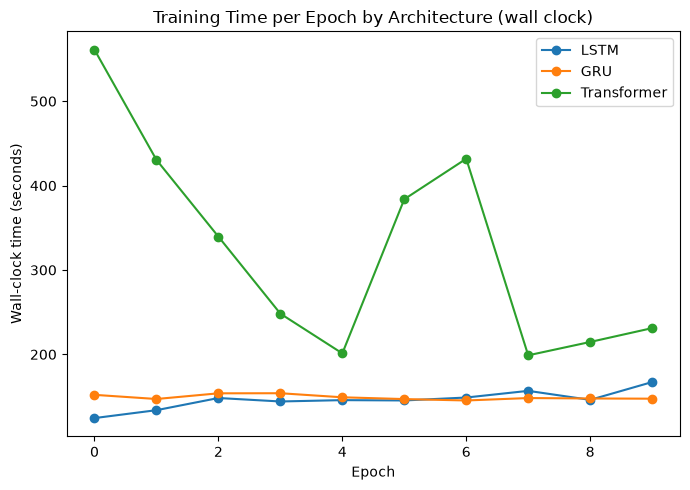

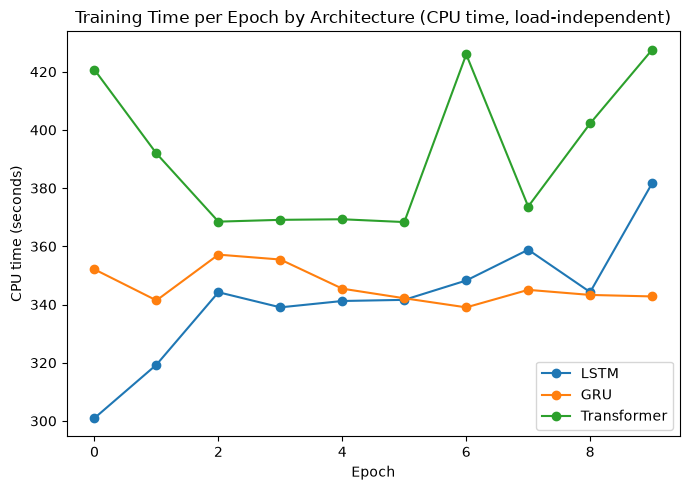

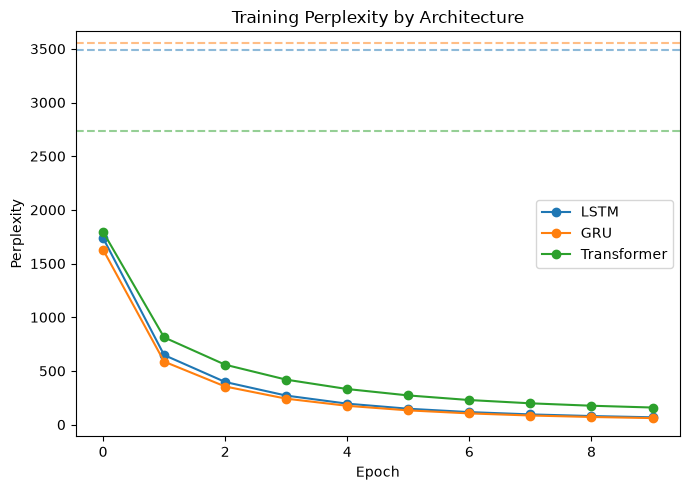

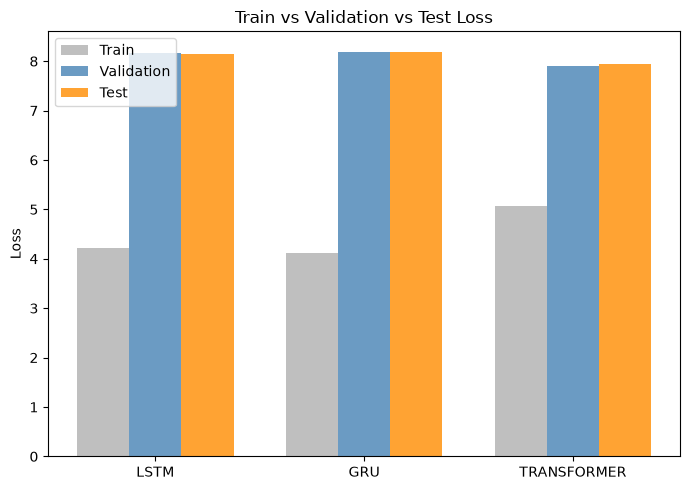

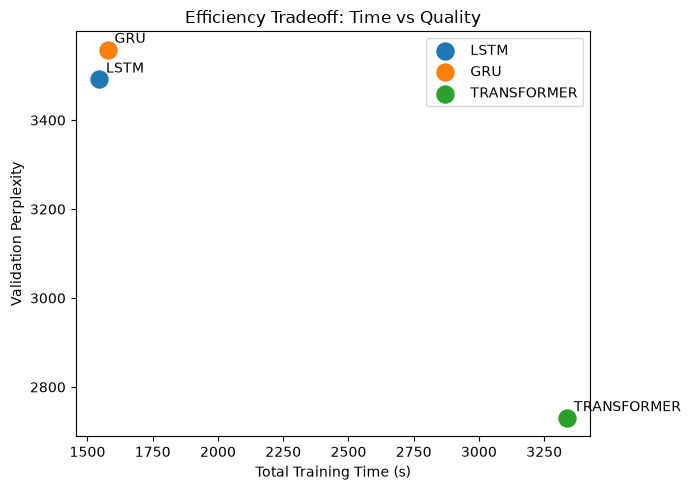

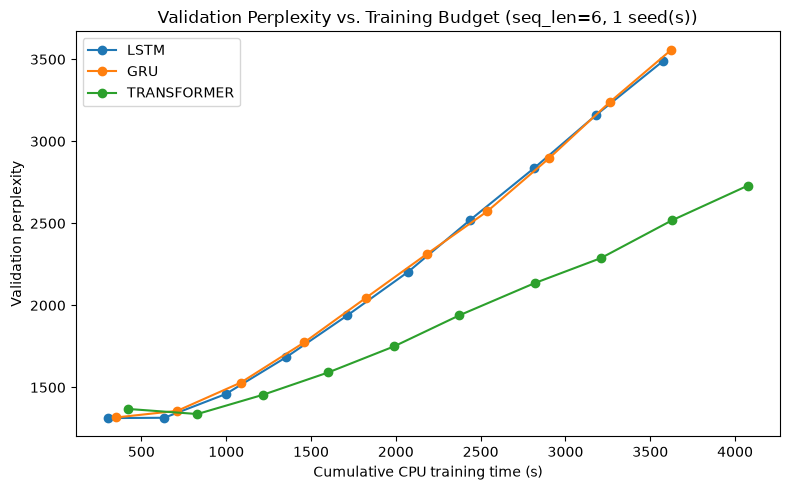

In [28]:
import os
os.makedirs('results', exist_ok=True)

# Panel 1a: wall-clock time (kept for comparison with the original plot)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(results['lstm']['epoch_times'], label='LSTM', marker='o')
ax.plot(results['gru']['epoch_times'], label='GRU', marker='o')
ax.plot(results['transformer']['epoch_times'], label='Transformer', marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Wall-clock time (seconds)')
ax.set_title('Training Time per Epoch by Architecture (wall clock)')
ax.legend()
fig.tight_layout()
fig.savefig('results/training_time_per_epoch_wallclock.png', dpi=150, bbox_inches='tight')
plt.show()

# Panel 1b: CPU time -- the fixed, load-independent metric
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(results['lstm']['epoch_cpu_times'], label='LSTM', marker='o')
ax.plot(results['gru']['epoch_cpu_times'], label='GRU', marker='o')
ax.plot(results['transformer']['epoch_cpu_times'], label='Transformer', marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('CPU time (seconds)')
ax.set_title('Training Time per Epoch by Architecture (CPU time, load-independent)')
ax.legend()
fig.tight_layout()
fig.savefig('results/training_time_per_epoch_by_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 2: training perplexity with val ppl as dashed line
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.exp(results['lstm']['epoch_losses']), label='LSTM', marker='o', color='C0')
ax.plot(np.exp(results['gru']['epoch_losses']), label='GRU', marker='o', color='C1')
ax.plot(np.exp(results['transformer']['epoch_losses']), label='Transformer', marker='o', color='C2')
ax.axhline(results['lstm']['val_ppl'], color='C0', linestyle='--', alpha=0.5)
ax.axhline(results['gru']['val_ppl'], color='C1', linestyle='--', alpha=0.5)
ax.axhline(results['transformer']['val_ppl'], color='C2', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
ax.set_title('Training Perplexity by Architecture')
ax.legend()
fig.tight_layout()
fig.savefig('results/training_ppl_with_val_ppl_as_dashed.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 3: train vs val vs test loss
fig, ax = plt.subplots(figsize=(7, 5))
models_list = ['lstm', 'gru', 'transformer']
x = np.arange(len(models_list))
width = 0.25
train_losses = [results[m]['epoch_losses'][-1] for m in models_list]
val_losses = [results[m]['val_loss'] for m in models_list]
test_losses = [results[m]['test_loss'] for m in models_list]
ax.bar(x - width, train_losses, width, label='Train', alpha=0.5, color='gray')
ax.bar(x, val_losses, width, label='Validation', alpha=0.8, color='steelblue')
ax.bar(x + width, test_losses, width, label='Test', alpha=0.8, color='darkorange')
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in models_list])
ax.set_ylabel('Loss'); ax.set_title('Train vs Validation vs Test Loss')
ax.legend()
fig.tight_layout()
fig.savefig('results/train_vs_validation_vs_test_loss.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 4: efficiency tradeoff (total time vs val ppl)
# `colors` was previously undefined -- fixed here.
colors = ['C0', 'C1', 'C2']
fig, ax = plt.subplots(figsize=(7, 5))
for m, c in zip(models_list, colors):
    total_time = results[m]['total_time']
    val_ppl = results[m]['val_ppl']
    ax.scatter(total_time, val_ppl, s=150, color=c, label=m.upper())
    ax.annotate(m.upper(), (total_time, val_ppl), textcoords='offset points', xytext=(5, 5))
ax.set_xlabel('Total Training Time (s)'); ax.set_ylabel('Validation Perplexity')
ax.set_title('Efficiency Tradeoff: Time vs Quality')
ax.legend()
fig.tight_layout()
fig.savefig('results/time_vs_val_ppl.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 5: validation perplexity vs. cumulative training budget
fig, ax = plt.subplots(figsize=(8, 5))
for arch, color in zip(models_list, colors):
    runs = [all_results[(SEQ_LEN, s)][arch] for s in SEEDS_TO_RUN if (SEQ_LEN, s) in all_results]
    if not runs:
        continue
    cum_time = np.mean([r['cumulative_cpu_time'] for r in runs], axis=0)
    val_ppl_curve = np.mean([r['epoch_val_ppls'] for r in runs], axis=0)
    ax.plot(cum_time, val_ppl_curve, marker='o', label=arch.upper(), color=color)
ax.set_xlabel('Cumulative CPU training time (s)'); ax.set_ylabel('Validation perplexity')
ax.set_title(f'Validation Perplexity vs. Training Budget (seq_len={SEQ_LEN}, {len(SEEDS_TO_RUN)} seed(s))')
ax.legend()
fig.tight_layout()
fig.savefig('results/val_ppl_vs_training_budget.png', dpi=150, bbox_inches='tight')
plt.show()


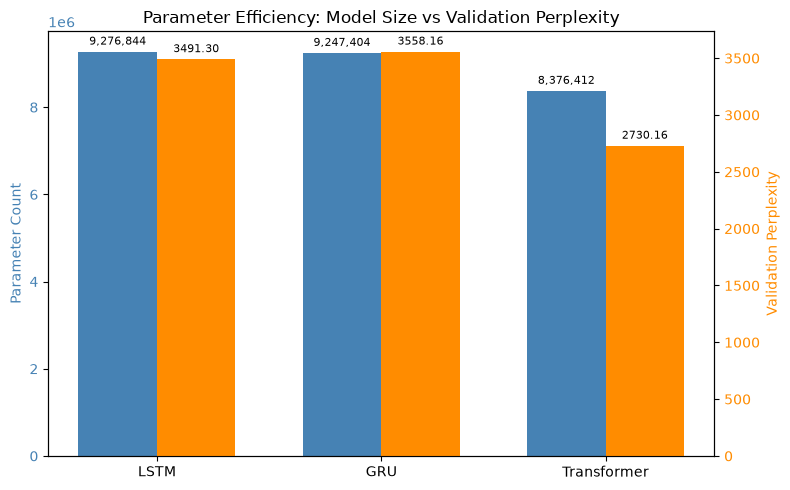

In [29]:
param_counts = {
    'LSTM': count_params(lstm_model),
    'GRU': count_params(gru_model),
    'Transformer': count_params(transformer_model),
}
val_ppls = {
    'LSTM': results['lstm']['val_ppl'],
    'GRU': results['gru']['val_ppl'],
    'Transformer': results['transformer']['val_ppl'],
}

fig, ax1 = plt.subplots(figsize=(8, 5))
model_names = list(param_counts.keys())
x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, [param_counts[m] for m in model_names], width, label='Parameters', color='steelblue')
ax1.set_ylabel('Parameter Count', color='steelblue')
ax1.set_xticks(x); ax1.set_xticklabels(model_names)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar(x + width/2, [val_ppls[m] for m in model_names], width, label='Val Perplexity', color='darkorange')
ax2.set_ylabel('Validation Perplexity', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

for i, m in enumerate(model_names):
    ax1.annotate(f'{param_counts[m]:,}', (x[i]-width/2, param_counts[m]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)
    ax2.annotate(f'{val_ppls[m]:.2f}', (x[i]+width/2, val_ppls[m]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.title('Parameter Efficiency: Model Size vs Validation Perplexity')
fig.tight_layout()
plt.savefig('results/param_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


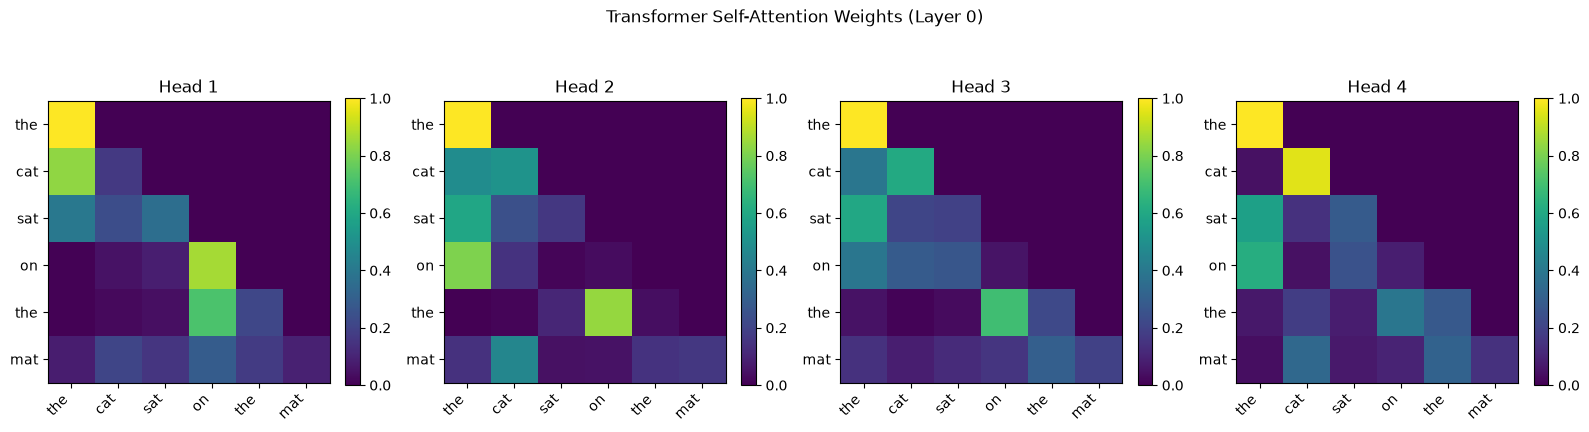

In [30]:
def get_attention_weights(model, sentence_tokens, layer_idx=0):
    model.eval()
    device = next(model.parameters()).device
    x = torch.tensor(sentence_tokens).unsqueeze(0).to(device)
    bsz, seq_len_local = x.shape
    pos_ids = torch.arange(seq_len_local, device=device).unsqueeze(0).expand(bsz, seq_len_local)

    with torch.no_grad():
        e = model.embedding(x) + model.pos_embedding(pos_ids)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len_local).to(device)
        padding_mask = (x == word_ind['<pad>'])  # fixed: was hardcoded 0, now matches actual pad token

        out = e
        for i, layer in enumerate(model.encoder.layers):
            if i == layer_idx:
                _, attn_weights = layer.self_attn(
                    out, out, out,
                    attn_mask=causal_mask,
                    key_padding_mask=padding_mask,
                    need_weights=True,
                    average_attn_weights=False,
                )
                return attn_weights.squeeze(0)
            out = layer(out, src_mask=causal_mask, src_key_padding_mask=padding_mask)

sample_sentence = "the cat sat on the mat"  # replace with a real sentence from your training data
sample_tokens = [word_ind.get(w, word_ind['<unk>']) for w in sample_sentence.split()]
attn_weights = get_attention_weights(transformer_model, sample_tokens, layer_idx=0)

nhead = attn_weights.shape[0]
fig, axes = plt.subplots(1, nhead, figsize=(4*nhead, 4))
if nhead == 1:
    axes = [axes]
for h in range(nhead):
    im = axes[h].imshow(attn_weights[h].cpu().numpy(), cmap='viridis')
    axes[h].set_xticks(range(len(sample_tokens)))
    axes[h].set_yticks(range(len(sample_tokens)))
    axes[h].set_xticklabels(sample_sentence.split(), rotation=45, ha='right')
    axes[h].set_yticklabels(sample_sentence.split())
    axes[h].set_title(f'Head {h+1}')
    plt.colorbar(im, ax=axes[h], fraction=0.046)
plt.suptitle('Transformer Self-Attention Weights (Layer 0)', y=1.05)
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print("LSTM:", sum(p.numel() for p in lstm_model.parameters()))
print("GRU:", sum(p.numel() for p in gru_model.parameters()))
print("Transformer:", sum(p.numel() for p in transformer_model.parameters()))

print(len(val_pad_predictors))
print(len(test_pad_predictors))

LSTM: 9276844
GRU: 9247404
Transformer: 8376412
112336
111274
